# CodeQL — RQ3 effect estimation and assessment

This restart-executable notebook retains the legacy developer-only versus developer-plus-third-party reporting-policy treatment and applies the current RQ1 graph assumptions. Association values are kept in the RQ1 result tables and are not printed on the graph.

In [1]:
from pathlib import Path
import sys
from IPython.display import SVG, display

REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / 'causal_analysis').is_dir():
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / 'causal_analysis').is_dir():
    raise RuntimeError('Run this notebook from the ci4security repository')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from causal_analysis.shared.rq3_analysis import run_rq3_analysis

/Users/mkhan04/Desktop/projects/CauSec/ci4security/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


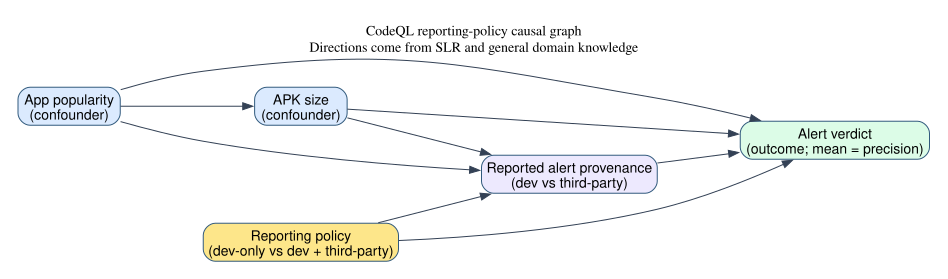

In [2]:
TOOL_NAME = 'CodeQL'
TOOL_SLUG = 'codeql'
DATA_PATH = REPO_ROOT / 'causal_analysis/data/codeql/alerts_with_lib_category_and_apk_size_codeql.csv'
GRAPH_PATH = REPO_ROOT / 'causal_analysis/rq1_graph_assessment/graphs/codeql_causal_graph.svg'
OUTPUT_DIR = REPO_ROOT / 'causal_analysis/rq3_effect_estimation/results/codeql'
BOOTSTRAP_SIMULATIONS = 1000
REFUTER_SIMULATIONS = 200
RANDOM_SEED = 20260915
display(SVG(filename=str(GRAPH_PATH)))

## Run the complete workflow

The workflow evaluates overlap and covariate balance; estimates the alert-row ATE risk difference with PSM, standardized logistic regression, and doubly robust AIPW; compares alert-row and popularity-stratified APK-cluster bootstraps; and runs the four legacy refuters plus an unobserved-common-cause sensitivity scenario.

In [3]:
analysis = run_rq3_analysis(
    tool_name=TOOL_NAME,
    source_path=DATA_PATH,
    graph_path=GRAPH_PATH,
    output_dir=OUTPUT_DIR,
    bootstrap_simulations=BOOTSTRAP_SIMULATIONS,
    refuter_simulations=REFUTER_SIMULATIONS,
    seed=RANDOM_SEED,
)
print(f'Results written to {OUTPUT_DIR}')

Results written to /Users/mkhan04/Desktop/projects/CauSec/ci4security/causal_analysis/rq3_effect_estimation/results/codeql


In [4]:
display(analysis['overlap'])
display(analysis['balance'])
display(analysis['matching'])
display(analysis['estimator_results'])
display(analysis['refuters'])
display(analysis['software_validation'])

,reporting_policy,reporting_scope,n_rows,ps_min,ps_q01,ps_q05,ps_q25,ps_median,ps_q75,ps_q95,ps_q99,ps_max,common_support_lower,common_support_upper,n_outside_common_support,percent_outside_common_support,n_extreme_ps_below_0_1_or_above_0_9
0,0,developer_only,554,0.966697,0.96708,0.968168,0.971775,0.975246,0.977377,0.979022,0.979790,0.979918,0.966697,0.979918,0,0.000000,554
1,1,developer_plus_third_party,21501,0.965138,0.96708,0.968577,0.972081,0.975818,0.977659,0.979498,0.979839,0.980008,0.966697,0.979918,227,1.055765,21501


,covariate,smd_before,abs_smd_before,smd_after_psm,abs_smd_after_psm,balanced_after_psm_at_0_1,smd_after_aipw_weighting,abs_smd_after_aipw_weighting,balanced_after_aipw_weighting_at_0_1
0,app_popularity_encoded,0.134773,0.134773,-0.029275,0.029275,True,0.003386,0.003386,True
1,apk_size_scaled,0.012463,0.012463,-0.081778,0.081778,True,0.004161,0.004161,True


,n_treated_rows,n_control_rows,common_support_lower,common_support_upper,n_rows_outside_common_support,percent_rows_outside_common_support,matching_with_replacement,unmatched_rows,unique_controls_used_for_att,unique_treated_used_for_atc,...,mean_atc_propensity_distance,max_atc_propensity_distance,diagnostic_logit_caliper_0_2_sd,att_pairs_above_diagnostic_caliper,atc_pairs_above_diagnostic_caliper,treated_effective_sample_size,control_effective_sample_size,aipw_treated_effective_sample_size,aipw_control_effective_sample_size,n_propensity_scores_clipped_at_0_01_or_0_99
0,21501,554,0.966697,0.979918,227,1.029245,True,0,155,154,...,0.0,0.0,0.027995,14,0,17971.072708,97.07905,21500.720427,544.131357,0


,estimator,estimator_label,effect_scale,target_units,estimate,row_bootstrap_successes,row_bootstrap_se,row_ci_low,row_ci_high,row_ci_width,row_ci_excludes_zero,cluster_bootstrap_successes,cluster_bootstrap_se,cluster_ci_low,cluster_ci_high,cluster_ci_width,cluster_ci_excludes_zero
0,psm,Propensity-score matching,risk_difference,ate,-0.057266,1000,0.018404,-0.095493,-0.023437,0.072056,True,1000,0.020963,-0.109836,-0.029543,0.080292,True
1,logistic_regression,Logistic-regression adjustment,risk_difference,ate,-0.064052,1000,0.008785,-0.079623,-0.045924,0.033699,True,1000,0.013214,-0.087788,-0.036495,0.051293,True
2,doubly_robust,Doubly robust (AIPW),risk_difference,ate,-0.059582,1000,0.009580,-0.077045,-0.039481,0.037564,True,1000,0.013861,-0.085313,-0.030855,0.054458,True


,estimator,refuter,result_index,original_effect,refuter_reference_effect,new_effect,absolute_change_from_original,relative_change_from_original,sign_changed_from_original,p_value,refuter_reports_significant_change,status,error
0,psm,random_common_cause,0,-0.057266,-0.057266,-0.057266,1.387779e-17,2.423394e-16,False,1.000,False,success,None
1,psm,placebo_treatment_refuter,0,-0.057266,-0.057266,0.007530,6.479619e-02,1.131496e+00,True,0.780,False,success,None
2,psm,data_subset_refuter,0,-0.057266,-0.057266,-0.074313,1.704744e-02,2.976890e-01,False,0.220,False,success,None
3,psm,dummy_outcome_refuter,0,-0.057266,0.000000,-0.016536,4.072984e-02,7.112404e-01,False,0.920,False,success,None
4,psm,add_unobserved_common_cause,0,-0.057266,-0.057266,0.627703,6.849694e-01,1.196120e+01,True,NaN,None,success,None
5,logistic_regression,random_common_cause,0,-0.064052,-0.064052,-0.064057,5.231341e-06,8.167316e-05,False,0.900,False,success,None
6,logistic_regression,placebo_treatment_refuter,0,-0.064052,-0.064052,0.000632,6.468464e-02,1.009875e+00,True,0.910,False,success,None
7,logistic_regression,data_subset_refuter,0,-0.064052,-0.064052,-0.064337,2.848079e-04,4.446500e-03,False,0.910,False,success,None
8,logistic_regression,dummy_outcome_refuter,0,-0.064052,0.000000,-0.005236,5.881656e-02,9.182606e-01,False,0.845,False,success,None
9,logistic_regression,add_unobserved_common_cause,0,-0.064052,-0.064052,0.504724,5.687760e-01,8.879890e+00,True,NaN,None,success,None


,estimator,dowhy_estimate,independent_implementation_estimate,difference,agrees_within_1e_8
0,psm,-0.057266,-0.057266,0.000000e+00,True
1,logistic_regression,-0.064052,-0.064052,1.249001e-16,True
2,doubly_robust,-0.059582,-0.059582,-3.608225e-16,True
